# Rain-Flow Event Matching and Summary
This notebook links observed flow events in the Gazelle Valley basin with rainfall data from three rain gauges (Gazelle Valley, Ziv, and Givat Ram), and summarizes the associated rainfall characteristics.

Key steps:
- Load and clean rainfall time series from the three stations.
- Load flow events and parse timestamp columns (start, end, and peak).
- Identify the start and end of the rainfall event responsible for each flow event.
- Calculate total rainfall, peak intensity (mm/hr), and its timing for each rain gauge and each event.
- Create a MultiIndex DataFrame combining discharge data with rainfall statistics.
- Assign event IDs based on the hydrological year (September–August).
- Filter out events where all stations recorded less than X mm of total rainfall.
- Visualize and analyze selected rainfall–runoff events.


# Imports

In [1]:
import pandas as pd
from datetime import timedelta

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


# Data load and parameter set

In [2]:
# === PARAMETERS ===
# RAIN_ACCUM_HOURS = 24
# RAIN_THRESHOLD_MM = 0.1
# STEP_HOURS = 12

RAIN_ACCUM_HOURS = 6
RAIN_THRESHOLD_MM = 0.1
STEP_HOURS = 24
MAX_STEPS = 100
TOTAL_RAIN_THRESHOLD_MM = 1
# === File paths ===
gv_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\gazelle_valley\20230921_20241117_processed.csv"
ziv_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\ziv\20230921_20241117_processed.csv"
ram_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\givat_ram\20231030_20250410_processed.csv"

# === Load rain data ===
gv_rain = pd.read_csv(gv_path, parse_dates=['date_time'])
ziv_rain = pd.read_csv(ziv_path, parse_dates=['date_time'])
ram_rain = pd.read_csv(ram_path, parse_dates=['date_time'])

rain_stations = [gv_rain, ziv_rain, ram_rain]
station_names = ['gazelle_valley', 'ziv', 'givat_ram']

for rain_df in rain_stations:
    rain_df.set_index('date_time', inplace=True)
    rain_df.sort_index(inplace=True)
    rain_df.index = rain_df.index.tz_localize(None)

# === Load and clean flow events ===
flow_events = pd.read_csv(r"D:\Development\RESEARCH\Gazelle_Valley\Data\discharge\flow_events_processed.csv")
flow_events['flow_start'] = pd.to_datetime(flow_events['flow_start_date'] + ' ' + flow_events['flow_start_time'], dayfirst=True, errors='coerce')
flow_events['flow_end'] = pd.to_datetime(flow_events['flow_end_date'] + ' ' + flow_events['flow_end_time'], dayfirst=True, errors='coerce')
flow_events.drop(columns=['flow_start_date', 'flow_start_time', 'flow_end_date', 'flow_end_time'], inplace=True)
flow_events.dropna(subset=['flow_start', 'flow_end'], inplace=True)

# Combine flow peak date + time
flow_events['flow_peak_datetime'] = pd.to_datetime(
    flow_events['flow_peak_date'].astype(str) + ' ' + flow_events['flow_peak_time'].astype(str),
    dayfirst=True, errors='coerce'
)
flow_events.drop(columns=['flow_peak_date', 'flow_peak_time'], inplace=True)

# Functions

In [3]:
# === Find rain boundary (start or end of rainfall event) ===
def find_rain_boundary(rain_dfs, flow_time, direction):
    delta = timedelta(hours=RAIN_ACCUM_HOURS)
    step = timedelta(hours=STEP_HOURS)
    current_times = [flow_time - step if direction == 'backward' else flow_time + step for _ in rain_dfs]
    steps = 0

    while steps < MAX_STEPS:
        all_below = []
        for i, rain_df in enumerate(rain_dfs):
            t = current_times[i]
            if direction == 'backward':
                rain_amount = rain_df.loc[t - delta:t]['rain_mm'].sum()
            else:
                rain_amount = rain_df.loc[t:t + delta]['rain_mm'].sum()

            if rain_amount < RAIN_THRESHOLD_MM:
                all_below.append(True)
            else:
                current_times[i] = current_times[i] - step if direction == 'backward' else current_times[i] + step
                all_below.append(False)

        if all(all_below):
            return max(current_times) if direction == 'backward' else min(current_times)
        steps += 1

    return None


# === Summarize rainfall statistics per station ===
def summarize_rain_events(rain_event_df, rain_df):
    total_mm, max_intensity, max_datetime = [], [], []
    for _, row in rain_event_df.iterrows():
        start, end = row['rain_event_start'], row['rain_event_end']
        event_rain = rain_df.loc[start:end]

        if event_rain.empty:
            # No data → treat as missing, not zero
            total = float('nan')
            max_val = float('nan')
            max_dt = pd.NaT
        else:
            total = event_rain['rain_mm'].sum()
            max_val = event_rain['rain_intens_10min_mm_hr'].max()
            if pd.notna(max_val):
                max_row = event_rain[event_rain['rain_intens_10min_mm_hr'] == max_val].iloc[0]
                max_dt = max_row.name
            else:
                max_dt = pd.NaT

        total_mm.append(total)
        max_intensity.append(max_val)
        max_datetime.append(max_dt)

    return total_mm, max_intensity, max_datetime



In [4]:
def assign_event_id(df, date_col='flow_start'):
    """
    Returns a new Series of event IDs based on rainy season logic:
    - Each rainy season starts in September and ends in August the next year.
    - Event ID is [season_index][event_number], e.g. 101, 102, ..., 201, 202...

    Parameters:
    - df (pd.DataFrame): The DataFrame containing the event dates.
    - date_col (str): The column name to base the season on (default: 'flow_start').

    Returns:
    - pd.Series: A Series of event IDs (Int64) with same index as df.
    """
    temp = df[[date_col]].copy()
    temp['season_year'] = temp[date_col].apply(lambda dt: dt.year if dt.month >= 9 else dt.year - 1)
    temp['season_index'] = temp['season_year'] - temp['season_year'].min() + 1
    temp['event_number'] = temp.groupby('season_year').cumcount() + 1
    event_ids = temp['season_index'] * 100 + temp['event_number']
    return event_ids.astype('Int64')


In [5]:
def filter_events_by_total_rain(df, threshold_mm, station_names=None):
    """
    Filters rainflow_events_df based on total rainfall threshold.
    Keeps events where at least one station has total_mm >= threshold.
    Ignores events where all values are below threshold or NaN.
    
    Parameters:
    - df (pd.DataFrame): MultiIndex DataFrame of events
    - threshold_mm (float): Rainfall threshold in mm
    - station_names (list of str): Names of the stations (e.g. ['gazelle_valley', 'ziv', 'givat_ram'])

    Returns:
    - pd.DataFrame: Filtered DataFrame
    """
    if station_names is None:
        station_names = ['gazelle_valley', 'ziv', 'givat_ram']
        
    mask = pd.Series(False, index=df.index)
    
    for name in station_names:
        rain = df[(name, 'total_mm')]
        valid_and_high = rain.notna() & (rain >= threshold_mm)
        mask = mask | valid_and_high

    return df[mask]


In [6]:
def calculate_runoff_coefficients(
    df: pd.DataFrame,
    station_names,
    area_km2: float = 2.0,
    vol_key = ('discharge', 'flow_total_volume_m3'),
    depth_key = ('discharge', 'runoff_depth_mm'),
    out_suffix: str = 'runoff_co'
) -> pd.DataFrame:
    """
    Adds per event runoff depth [mm] and per station runoff coefficient.
    Units: V[m^3], A[km^2] -> depth_mm = 1000 * V / (A*1e6), C = depth_mm / rain_mm
    """
    area_m2 = float(area_km2) * 1_000_000.0
    if vol_key not in df.columns:
        raise KeyError(f"Missing volume column {vol_key}")

    # runoff depth [mm]
    v = pd.to_numeric(df[vol_key], errors='coerce')
    depth_mm = 1000.0 * v / area_m2
    df[depth_key] = depth_mm

    # per station runoff coefficient
    for name in station_names:
        rain_key = (name, 'total_mm')
        if rain_key in df.columns:
            rain_mm = pd.to_numeric(df[rain_key], errors='coerce')
            co = depth_mm / rain_mm
            co = co.where(rain_mm > 0)  # avoid divide by zero and non positive rain
            df[(name, out_suffix)] = co

    return df


# Main

In [7]:
area_km2 = 1.1

# === Determine rain event start and end for each flow event ===
rain_start_list, rain_end_list = [], []

for _, row in flow_events.iterrows():
    start_dt = row['flow_start']
    end_dt = row['flow_end']
    rain_start = find_rain_boundary(rain_stations, start_dt, direction='backward')
    rain_end = find_rain_boundary(rain_stations, end_dt, direction='forward')
    rain_start_list.append(rain_start)
    rain_end_list.append(rain_end)

flow_events['rain_event_start'] = rain_start_list
flow_events['rain_event_end'] = rain_end_list


# === Build MultiIndex dataframe ===
multi_df = {}

# Add non-time flow data
for col in flow_events.columns.difference(['flow_start', 'flow_end', 'rain_event_start', 'rain_event_end']):
    multi_df[('discharge', col)] = flow_events[col]

# Add rain timing
multi_df[('rain', 'rain_event_start')] = flow_events['rain_event_start']
multi_df[('rain', 'rain_event_end')] = flow_events['rain_event_end']

# Add stats per station
for rain_df, name in zip(rain_stations, station_names):
    total_mm, max_intensity, max_datetime = summarize_rain_events(flow_events, rain_df)
    multi_df[(name, 'total_mm')] = total_mm
    multi_df[(name, 'max_intens_10min_mm_hr')] = max_intensity
    multi_df[(name, 'max_intens_10min_datetime')] = max_datetime

# Final dataframe
raw_rainflow_events_df = pd.DataFrame(multi_df)
raw_rainflow_events_df.columns = pd.MultiIndex.from_tuples(raw_rainflow_events_df.columns)

# Add per station runoff coefficients (area = 2 km^2)
raw_rainflow_events_df = calculate_runoff_coefficients(raw_rainflow_events_df, station_names, area_km2=area_km2)


## Filter event by total event rainfall

In [8]:
# Filter events based on rainfall threshold and create a copy to avoid warnings
rainflow_events_df = filter_events_by_total_rain(raw_rainflow_events_df, TOTAL_RAIN_THRESHOLD_MM).copy()
print(f"Filtered out {len(raw_rainflow_events_df) - len(rainflow_events_df)} events below threshold.")

# Add flow_start explicitly to the filtered DataFrame (for assigning seasonal IDs)
rainflow_events_df[('discharge', 'flow_start')] = flow_events.loc[
    rainflow_events_df.index, 'flow_start'
].values

# Create season index based on flow_start
flow_start_series = rainflow_events_df[('discharge', 'flow_start')]
rainflow_events_df['season_index'] = assign_event_id(pd.DataFrame({'flow_start': flow_start_series}))

# Reorder so that for each station: total_mm then runoff_co, then the rest (visual only)
_all_cols = list(rainflow_events_df.columns)
_tuple_cols = [c for c in _all_cols if isinstance(c, tuple)]
_other_cols = [c for c in _all_cols if not isinstance(c, tuple)]  # includes 'season_index'

_non_station_tuple = [c for c in _tuple_cols if c[0] not in station_names]

_ordered_station_cols = []
for _name in station_names:  # e.g., ['gazelle_valley', 'ziv', 'givat_ram']
    _sub = [c for c in _tuple_cols if c[0] == _name]
    if not _sub:
        continue
    _wanted = []
    if (_name, 'total_mm') in _sub:
        _wanted.append((_name, 'total_mm'))
    if (_name, 'runoff_co') in _sub:
        _wanted.append((_name, 'runoff_co'))
    _remaining = [c for c in _sub if c not in _wanted]  # keep original order for the rest
    _ordered_station_cols.extend(_wanted + _remaining)

_new_cols = _other_cols + _non_station_tuple + _ordered_station_cols
_seen = set()
_new_cols = [c for c in _new_cols if not (c in _seen or _seen.add(c))]
rainflow_events_df = rainflow_events_df.reindex(columns=_new_cols)

# Set season_index as the final index
rainflow_events_df.set_index('season_index', inplace=True)


Filtered out 15 events below threshold.


In [9]:
rainflow_events_df

discharge                                      \
              flow_peak_datetime flow_peak_m3_s flow_total_volume_m3   
season_index                                                           
101          2023-11-01 13:50:00       0.617218          1773.301946   
102          2023-11-14 16:40:00       0.063550            39.911987   
103          2023-11-20 02:55:00       0.394052          7530.163635   
104          2023-11-27 13:30:00       0.218358          2319.086856   
105          2023-12-05 17:50:00       0.166977           545.809527   
106          2023-12-13 06:00:00       0.247912          1022.017072   
107          2023-12-24 06:05:00       0.306212          5235.336201   
108          2024-01-02 09:35:00       0.283269         10427.108320   
109          2024-01-12 04:50:00       0.292369         10366.953362   
110          2024-01-26 17:15:00       0.399168         17738.155378   
111          2024-02-02 07:45:00       0.198052          5783.383577   
112          2024-02-14 04:50:00       0.038764            60.869573   
113          2024-02-19 06:15:00       0.265381          4853.161293   
114          2024-02-27 13:15:00       0.155777          1065.196421   
115          2024-03-03 09:45:00       0.023595             7.537237   
116          2024-03-19 09:05:00       0.889764         14551.698733   
117          2024-05-06 10:35:00       0.159483           187.342221   
201          2024-11-02 15:05:00       0.163216           130.210958   
202          2024-11-26 04:10:00       0.218358           645.201718   
203          2024-12-20 12:25:00       0.178424           327.618529   
204          2024-12-31 12:00:00       0.599202          8685.899560   
205          2025-01-11 04:50:00       0.033586            35.699259   
206          2025-02-05 21:15:00       0.896697          8231.422792   
207          2025-02-09 23:10:00       0.063550            90.011656   
208          2025-02-20 10:30:00       0.889764          1620.773314   
209          2025-03-07 06:25:00       0.182295          1090.477842   
210          2025-03-20 18:30:00       0.301572          2665.734221   
211          2025-04-14 02:35:00       0.320285           781.407425   
301          2025-11-15 12:05:00       2.754844          5678.974110   

                            rain                           discharge  \
                rain_event_start      rain_event_end runoff_depth_mm   
season_index                                                           
101          2023-10-31 12:20:00 2023-11-04 11:00:00        1.612093   
102          2023-11-13 16:30:00 2023-11-15 17:05:00        0.036284   
103          2023-11-18 14:20:00 2023-11-22 16:15:00        6.845603   
104          2023-11-26 04:05:00 2023-11-28 18:10:00        2.108261   
105          2023-12-04 16:20:00 2023-12-07 12:40:00        0.496190   
106          2023-12-12 04:35:00 2023-12-14 15:30:00        0.929106   
107          2023-12-21 05:55:00 2023-12-25 16:55:00        4.759397   
108          2024-01-01 02:40:00 2024-01-03 21:20:00        9.479189   
109          2024-01-09 23:50:00 2024-01-16 11:40:00        9.424503   
110          2024-01-22 13:20:00 2024-01-31 11:05:00       16.125596   
111          2024-02-01 00:25:00 2024-02-08 01:25:00        5.257621   
112          2024-02-12 09:30:00 2024-02-15 05:20:00        0.055336   
113          2024-02-17 11:00:00 2024-02-23 20:15:00        4.411965   
114          2024-02-26 13:10:00 2024-02-29 15:25:00        0.968360   
115          2024-03-02 09:40:00 2024-03-04 10:00:00        0.006852   
116          2024-03-17 14:55:00 2024-03-20 17:35:00       13.228817   
117          2024-05-05 06:25:00 2024-05-07 11:40:00        0.170311   
201          2024-11-01 14:55:00 2024-11-03 15:30:00        0.118374   
202          2024-11-24 23:20:00 2024-11-27 04:50:00        0.586547   
203          2024-12-19 11:40:00 2024-12-21 13:05:00        0.297835   
204          2024-12-27 10:05:00 2025-01-01 13:55:00        7.

In [10]:
rainflow_events_df.columns

MultiIndex([(     'discharge',        'flow_peak_datetime'),
            (     'discharge',            'flow_peak_m3_s'),
            (     'discharge',      'flow_total_volume_m3'),
            (          'rain',          'rain_event_start'),
            (          'rain',            'rain_event_end'),
            (     'discharge',           'runoff_depth_mm'),
            (     'discharge',                'flow_start'),
            ('gazelle_valley',                  'total_mm'),
            ('gazelle_valley',                 'runoff_co'),
            ('gazelle_valley',    'max_intens_10min_mm_hr'),
            ('gazelle_valley', 'max_intens_10min_datetime'),
            (           'ziv',                  'total_mm'),
            (           'ziv',                 'runoff_co'),
            (           'ziv',    'max_intens_10min_mm_hr'),
            (           'ziv', 'max_intens_10min_datetime'),
            (     'givat_ram',                  'total_mm'),
            (     'givat

## Save to CSV

In [11]:
output_csv_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\discharge\flow_rain_events.csv"
rainflow_events_df.to_csv(output_csv_path)
print(f"✅ Saved full rain–flow event table to:\n{output_csv_path}")

✅ Saved full rain–flow event table to:
D:\Development\RESEARCH\Gazelle_Valley\Data\discharge\flow_rain_events.csv


# Plot

gazelle_valley: median runoff coefficient = 0.136
ziv: median runoff coefficient = 0.109
givat_ram: median runoff coefficient = 0.090


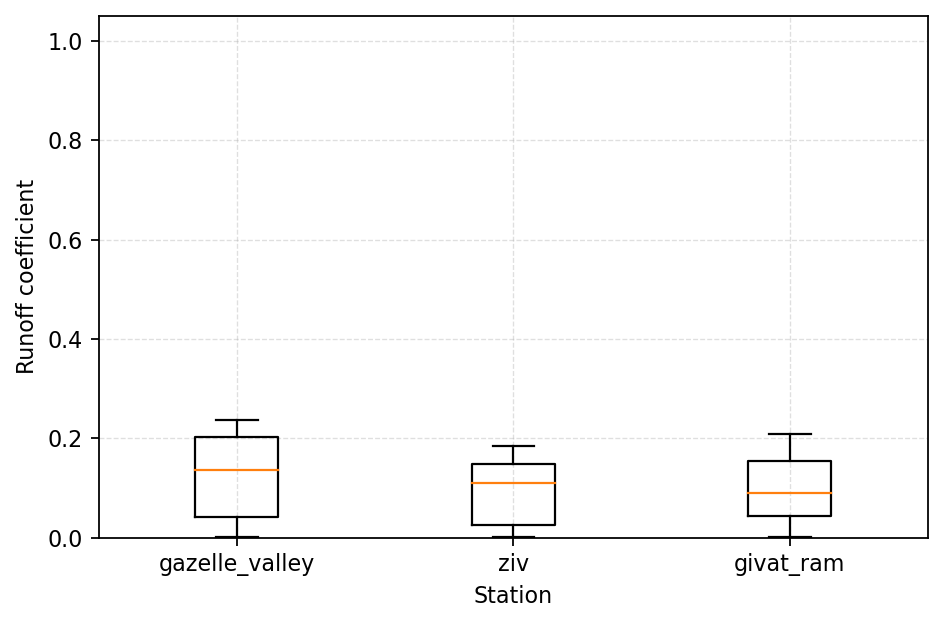

In [12]:
import numpy as np

_stations = [s for s in station_names if (s, 'runoff_co') in rainflow_events_df.columns]
_data = [pd.to_numeric(rainflow_events_df[(s, 'runoff_co')], errors='coerce').dropna().values
         for s in _stations]

# Print medians
for s, d in zip(_stations, _data):
    if len(d) > 0:
        print(f"{s}: median runoff coefficient = {np.median(d):.3f}")
#         print(f"{s}: mean runoff coefficient = {np.mean(d):.3f}")
#         print(f"{s}: max runoff coefficient = {np.max(d):.3f}")
#         print(f"{s}: min runoff coefficient = {np.min(d):.3f}")
    else:
        print(f"{s}: no data")

# Plot
fig, ax = plt.subplots(figsize=(6, 4), dpi=160)
ax.boxplot(_data, labels=_stations, showfliers=True)
ax.set_ylabel('Runoff coefficient')
ax.set_xlabel('Station')
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.6)
plt.tight_layout()
plt.show()


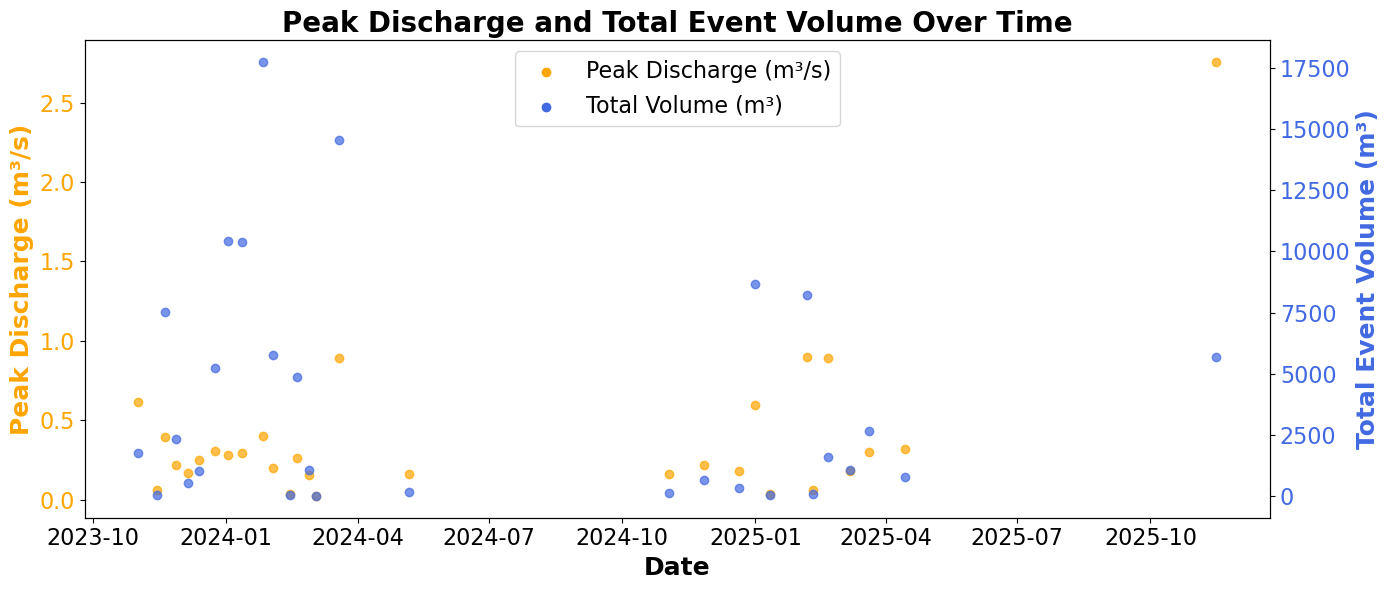

In [13]:
# Font size settings
axis_fontsize = 16
label_fontsize = 18
title_fontsize = 20
legend_fontsize = 16

dates = rainflow_events_df[('discharge', 'flow_peak_datetime')]
peak_flow = rainflow_events_df[('discharge', 'flow_peak_m3_s')]
total_volume = rainflow_events_df[('discharge', 'flow_total_volume_m3')]

fig, ax1 = plt.subplots(figsize=(14, 6))

# Left Y-axis: Peak Discharge
color_peak = 'orange'
ax1.scatter(dates, peak_flow, color=color_peak, alpha=0.7, label="Peak Discharge (m³/s)")
ax1.set_ylabel("Peak Discharge (m³/s)", color=color_peak, fontsize=label_fontsize, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_peak, labelsize=axis_fontsize)
ax1.set_xlabel("Date", fontsize=label_fontsize, fontweight='bold')
ax1.tick_params(axis='x', labelsize=axis_fontsize)

# Right Y-axis: Total Event Volume
ax2 = ax1.twinx()
color_vol = 'royalblue'
ax2.scatter(dates, total_volume, color=color_vol, alpha=0.7, label="Total Volume (m³)")
ax2.set_ylabel("Total Event Volume (m³)", color=color_vol, fontsize=label_fontsize, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_vol, labelsize=axis_fontsize)

plt.title("Peak Discharge and Total Event Volume Over Time", fontsize=title_fontsize, fontweight='bold')

# Legend
lns1 = ax1.scatter([], [], color=color_peak, label="Peak Discharge (m³/s)")
lns2 = ax2.scatter([], [], color=color_vol, label="Total Volume (m³)")
plt.legend([lns1, lns2], 
           ["Peak Discharge (m³/s)", "Total Volume (m³)"], 
           loc="upper center", fontsize=legend_fontsize, frameon=True)

fig.tight_layout()
plt.show()


### Rain

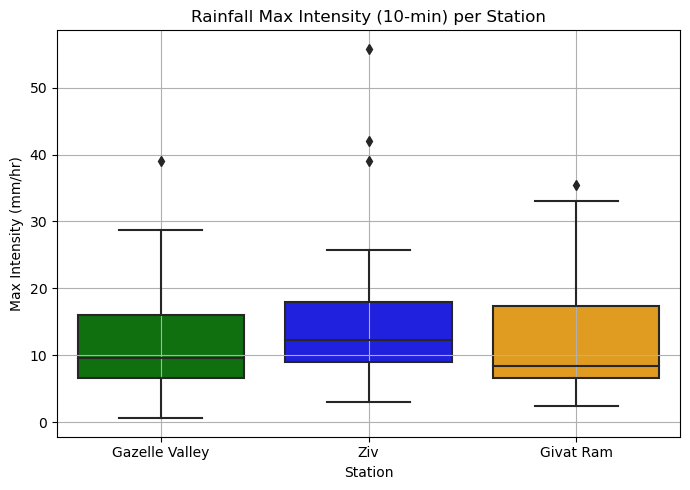

In [14]:
# Define colors for each station name as it appears in the 'Station' column
colors_box = {
    'Gazelle Valley': 'green',
    'Ziv': 'blue',
    'Givat Ram': 'orange'
}

# Create a long-format DataFrame for the boxplot
box_df = pd.DataFrame({
    'Gazelle Valley': rainflow_events_df[('gazelle_valley', 'max_intens_10min_mm_hr')],
    'Ziv': rainflow_events_df[('ziv', 'max_intens_10min_mm_hr')],
    'Givat Ram': rainflow_events_df[('givat_ram', 'max_intens_10min_mm_hr')],
})
box_df = box_df.melt(var_name='Station', value_name='Max Intensity (mm/hr)')

# Plot the boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(data=box_df, x='Station', y='Max Intensity (mm/hr)', palette=colors_box)
plt.title('Rainfall Max Intensity (10-min) per Station')
plt.grid(True)
plt.tight_layout()
plt.show()


### Discharge

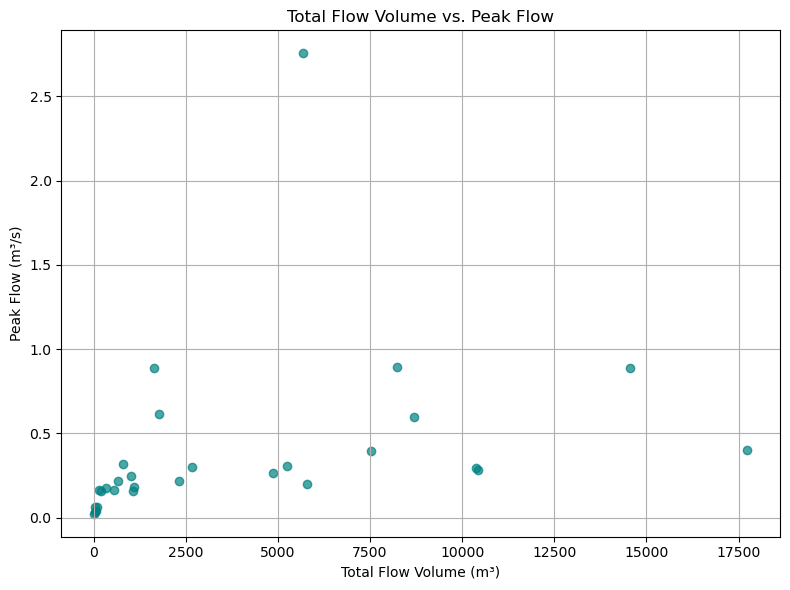

In [15]:
plt.figure(figsize=(8, 6))

volume = rainflow_events_df[('discharge', 'flow_total_volume_m3')]
peak = rainflow_events_df[('discharge', 'flow_peak_m3_s')]

valid = volume.notna() & peak.notna()

plt.scatter(volume[valid], peak[valid], alpha=0.7, color='teal')
plt.xlabel('Total Flow Volume (m³)')
plt.ylabel('Peak Flow (m³/s)')
plt.title('Total Flow Volume vs. Peak Flow')
plt.grid(True)
plt.tight_layout()
plt.show()


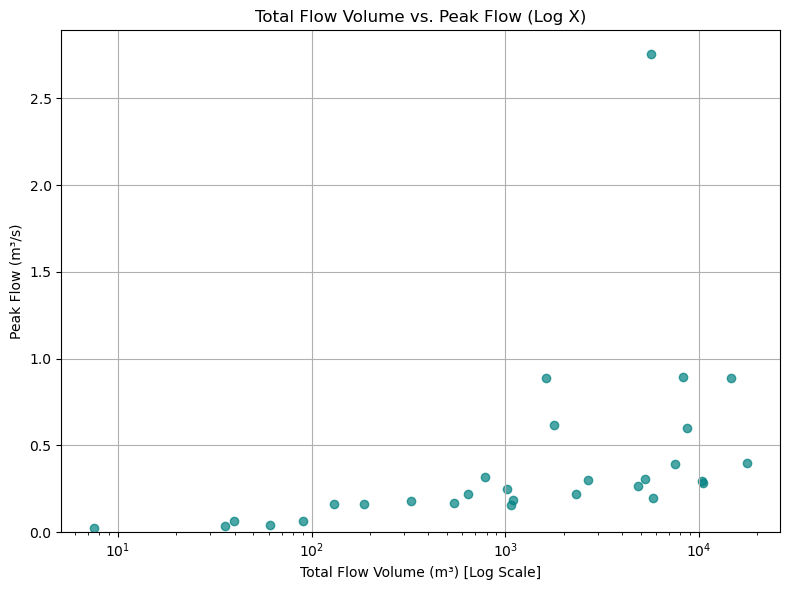

In [16]:
plt.figure(figsize=(8, 6))

volume = rainflow_events_df[('discharge', 'flow_total_volume_m3')]
peak = rainflow_events_df[('discharge', 'flow_peak_m3_s')]

valid = volume.notna() & peak.notna() & (volume > 0)

plt.scatter(volume[valid], peak[valid], alpha=0.7, color='teal')
plt.xscale('log')  # Logarithmic X-axis

# Labels and title
plt.ylim(0)
plt.xlabel('Total Flow Volume (m³) [Log Scale]')
plt.ylabel('Peak Flow (m³/s)')
plt.title('Total Flow Volume vs. Peak Flow (Log X)')

# Clean grid: only major ticks on X
plt.grid(True, which='major', axis='x')
plt.grid(True, axis='y')  # Keep normal grid on Y if you want

plt.tight_layout()
plt.show()


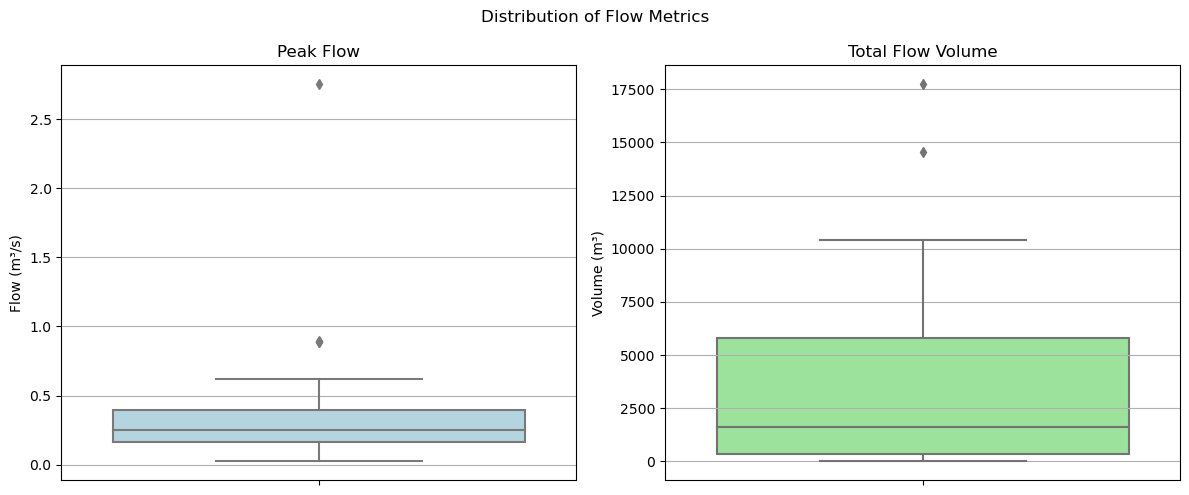

In [17]:
# Prepare data
peak_flow = rainflow_events_df[('discharge', 'flow_peak_m3_s')]
total_volume = rainflow_events_df[('discharge', 'flow_total_volume_m3')]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for peak flow
sns.boxplot(y=peak_flow, color='lightblue', ax=axes[0])
axes[0].set_title('Peak Flow')
axes[0].set_ylabel('Flow (m³/s)')
axes[0].grid(True, axis='y')

# Boxplot for total volume
sns.boxplot(y=total_volume, color='lightgreen', ax=axes[1])
axes[1].set_title('Total Flow Volume')
axes[1].set_ylabel('Volume (m³)')
axes[1].grid(True, axis='y')

plt.suptitle('Distribution of Flow Metrics')
plt.tight_layout()
plt.show()


### Rain and discharge

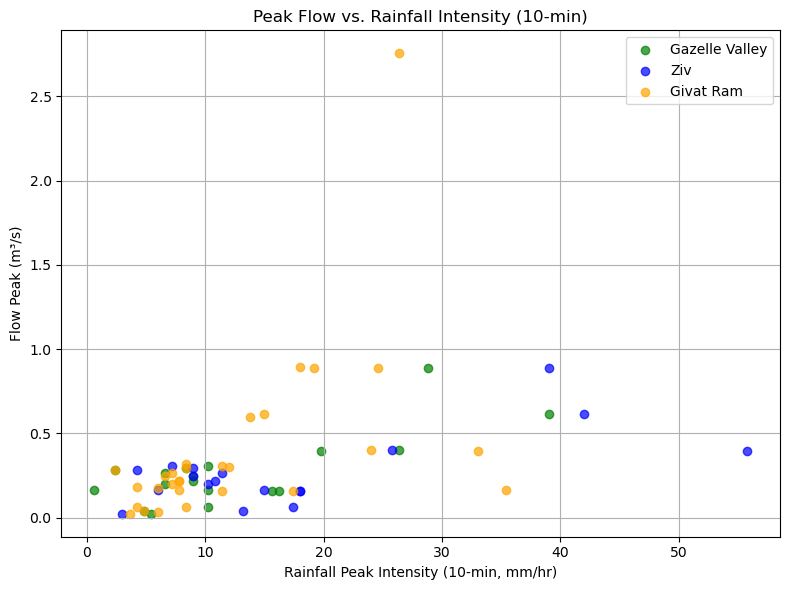

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
colors = {'gazelle_valley': 'green', 'ziv': 'blue', 'givat_ram': 'orange'}

for station in ['gazelle_valley', 'ziv', 'givat_ram']:
    intensity = rainflow_events_df[(station, 'max_intens_10min_mm_hr')]
    peak_flow = rainflow_events_df[('discharge', 'flow_peak_m3_s')]
    valid = intensity.notna() & peak_flow.notna()
    plt.scatter(intensity[valid], peak_flow[valid],
                label=station.replace('_', ' ').title(),
                color=colors[station], alpha=0.7)

plt.xlabel('Rainfall Peak Intensity (10-min, mm/hr)')
plt.ylabel('Flow Peak (m³/s)')
plt.title('Peak Flow vs. Rainfall Intensity (10-min)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


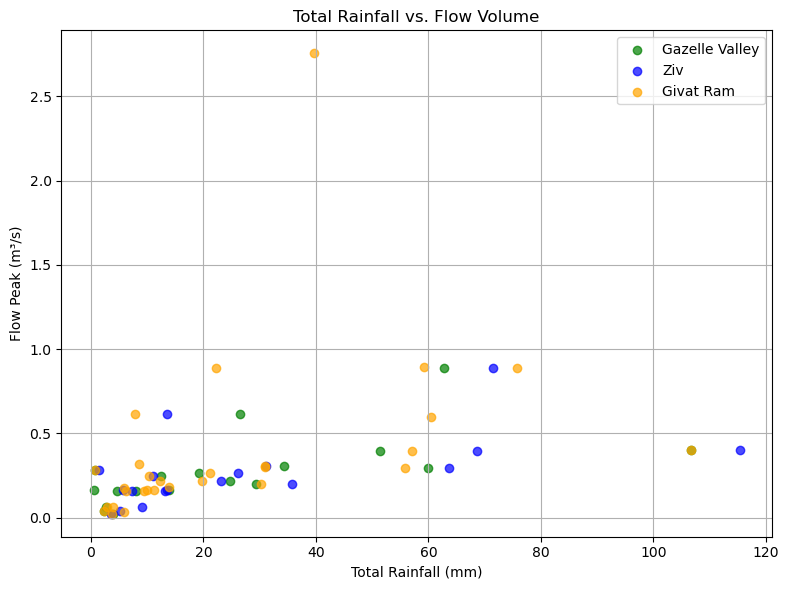

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
colors = {'gazelle_valley': 'green', 'ziv': 'blue', 'givat_ram': 'orange'}

for station in ['gazelle_valley', 'ziv', 'givat_ram']:
    intensity = rainflow_events_df[(station, 'total_mm')]
    peak_flow = rainflow_events_df[('discharge', 'flow_peak_m3_s')]
    valid = intensity.notna() & peak_flow.notna()
    plt.scatter(intensity[valid], peak_flow[valid],
                label=station.replace('_', ' ').title(),
                color=colors[station], alpha=0.7)

plt.xlabel('Total Rainfall (mm)')
plt.ylabel('Flow Peak (m³/s)')
plt.title('Total Rainfall vs. Flow Volume')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


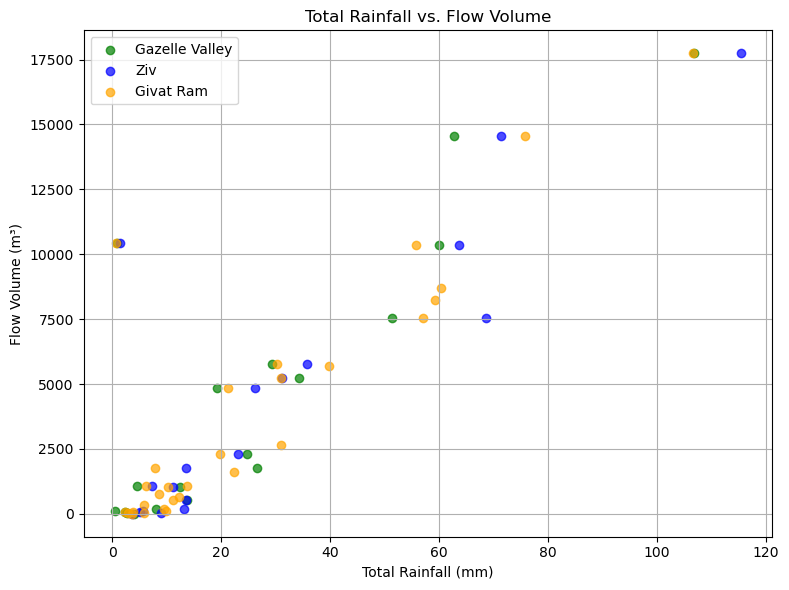

In [19]:
plt.figure(figsize=(8, 6))

for station in ['gazelle_valley', 'ziv', 'givat_ram']:
    rain = rainflow_events_df[(station, 'total_mm')]
    volume = rainflow_events_df[('discharge', 'flow_total_volume_m3')]
    valid = rain.notna() & volume.notna()
    plt.scatter(rain[valid], volume[valid],
                label=station.replace('_', ' ').title(),
                color=colors[station], alpha=0.7)

plt.xlabel('Total Rainfall (mm)')
plt.ylabel('Flow Volume (m³)')
plt.title('Total Rainfall vs. Flow Volume')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## rain events Vs flow events

In [20]:
# Load the rain events table (generated in the other notebook)
rain_events_path = r"D:\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\rain_events_givat_ram.csv"
rain_events_df = pd.read_csv(rain_events_path, parse_dates=['rain_event_start', 'rain_event_end'])


In [21]:
unmatched_rain_events = []

# Make sure datetime is correct
rain_events_df['rain_event_start'] = pd.to_datetime(rain_events_df['rain_event_start']).dt.tz_localize(None)
flow_events['rain_event_start'] = pd.to_datetime(flow_events['rain_event_start']).dt.tz_localize(None)
flow_events['rain_event_end'] = pd.to_datetime(flow_events['rain_event_end']).dt.tz_localize(None)

# Check each rain event
for _, rain_row in rain_events_df.iterrows():
    rain_start = rain_row['rain_event_start']

    # Check if rain_start falls within any rain_event_start–end in flow_events
    is_covered = ((flow_events['rain_event_start'] <= rain_start) &
                  (flow_events['rain_event_end'] >= rain_start)).any()

    if not is_covered:
        unmatched_rain_events.append(rain_row)

# Results
unmatched_df = pd.DataFrame(unmatched_rain_events)

print(f"💧 Total rain events: {len(rain_events_df)}")
print(f"✅ Rain events with associated flow: {len(rain_events_df) - len(unmatched_df)}")
print(f"❌ Rain events with NO associated flow: {len(unmatched_df)}")

print("\n📅 Rain events with no associated flow:")
print(unmatched_df[['rain_event_start', 'rain_event_end', 'total_rain_mm']])


💧 Total rain events: 65
✅ Rain events with associated flow: 51
❌ Rain events with NO associated flow: 14

📅 Rain events with no associated flow:
      rain_event_start      rain_event_end  total_rain_mm
6  2023-12-09 00:20:00 2023-12-09 00:40:00            1.3
22 2024-02-15 14:40:00 2024-02-15 14:50:00            1.3
28 2024-03-07 02:10:00 2024-03-07 11:30:00            1.0
30 2024-04-10 02:20:00 2024-04-10 12:10:00            5.0
34 2024-11-18 07:00:00 2024-11-18 10:30:00            0.8
35 2024-11-24 10:50:00 2024-11-25 00:20:00            5.2
37 2024-11-27 21:30:00 2024-11-28 07:20:00            2.7
39 2024-12-21 13:20:00 2024-12-21 14:00:00            0.8
44 2025-01-23 01:00:00 2025-01-23 15:20:00            3.1
47 2025-02-12 12:10:00 2025-02-13 07:00:00            5.5
56 2025-03-29 05:00:00 2025-03-29 11:00:00            1.1
57 2025-04-06 15:00:00 2025-04-06 15:10:00            0.8
58 2025-04-12 02:20:00 2025-04-12 13:00:00            1.8
61 2025-09-25 01:40:00 2025-09-25 01:50:00 

In [23]:
צריך למצוא דרך שזו תיהיה אותו לוגיקה של חיתוך אירועי גשם כמו הלוגיקה של חיתוך אירוע בהתאם לספיקה.
אחת וזה יקרה אפשר להציב אותן באותה טבלה.

אולי ללכת רק על הלוגיקה של חיתוך אירועי גשם ואז לבדוק איזה אירועי ספיקה מתאימים להם.
כלומר לא ללכת דרך אירועי הספיקה אלא דרך אירועי הגשם לאירועי הספיקה.

SyntaxError: invalid syntax (1360233040.py, line 1)